In [28]:
import pandas as pd
import matplotlib.pyplot as plt 

1. Прочитайте файл visits.csv, указав как разделитель знак табуляции: '\t', и сохраните результат в датафрейме data. Выведите его первые пять строк.

In [2]:
data = pd.read_csv('./visits.csv', sep='\t')
data.head()

,date_time,id,time_spent,name
0,20180406T165358,76144fb2,98.0,Василёк
1,20180404T173913,76144fb2,15.0,Василёк
2,20180403T172824,76144fb2,220.0,Василёк
3,20180407T070441,76144fb2,19.0,Василёк
4,20180404T132049,76144fb2,14.0,Василёк


2. Посчитайте среднее время заправки в секундах ('time_spent') для каждой из сетей ('name'), применяя метод pivot_table(). 

Датафрейм сохраните в переменной name_stat и выведите на экран.

In [3]:
# группируем таблицу по name, для каждого находим среднюю посещаемость
name_stat = data.pivot_table(index='name', values='time_spent') 
name_stat

,time_spent
name,
Агератум,337.802721
Амарант,132.760012
Аммобиум,256.708042
Арктотис,73.879984
Астильба,376.143149
Бальзамин,134.508411
Бархатцы,145.300328
Бегония,163.200647
Белоцветник,100.818966


3.1 Сколько было заездов на АЗС? Сохраните число строк датафрейма в переменной total_visits. Результат выведите на экран так: Количество заездов: ... 

In [4]:
total_visits = data['id'].count()
print(f'Количество заездов: ', total_visits)

Количество заездов:  317104


In [5]:
data.shape

(317104, 4)

3.2 Найдите количество охваченных исследованием АЗС. Сохраните его в переменной total_stations, результат на экран выведите так:

Количество АЗС: ... 

In [6]:
total_stations = len(data['name'].unique())
print('Количество АЗС: ', total_stations)

Количество АЗС:  45


3.3 Выведите на экран дату и время первого и последнего заезда на АЗС через пробел. 

Без объявления новых переменных, примените методы min() и max() к значениям столбца data['date_time'] в аргументе функции print().

Вывод должен выглядеть так: 20180402T000008 20180408T235957.

In [7]:
print(data['date_time'].min(),  data['date_time'].max())

20180402T000008 20180408T235957


3.4 Данные собраны за 7 дней — сохраните это значение в переменной total_days.

Найдите среднее число заездов на одну АЗС за 1 день. Сохраните результат вычислений в переменной station_visits_per_day и выведите её на экран в следующем виде:

Количество заездов на АЗС в сутки: ... 

In [8]:
total_days = 7

station_visits_per_day = total_visits/total_stations/total_days
print(f'Количество заездов на АЗС в сутки: ', station_visits_per_day)

Количество заездов на АЗС в сутки:  1006.6793650793651


3. 5 Проверьте распределение числа заездов по сетям АЗС. 

Распечатайте топ-10 сетей с наибольшим числом заездов. В каждой строке должно быть название сети и число заездов.

Результат выведите в функции print().

In [9]:

data_name = data['name'].value_counts().sort_values(ascending=False)
data_name.head()

name
Календула      85648
Василёк        79006
Георгина       34356
Немезия        20138
Колокольчик    18835
Name: count, dtype: int64

4.1  Выведите гистограмму значений времени, проведённого на АЗС.

array([[<Axes: title={'center': 'time_spent'}>]], dtype=object)

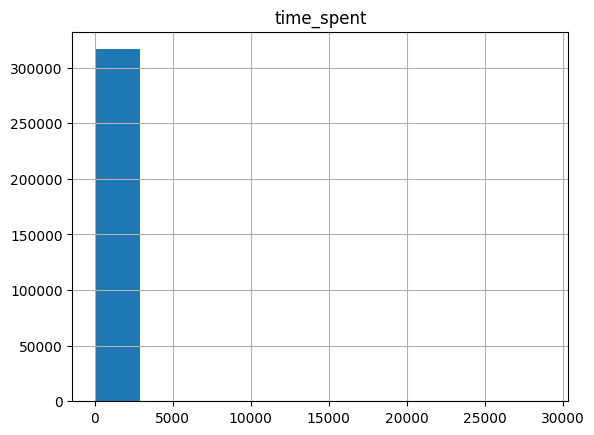

In [10]:
data.hist('time_spent')

4.2 Выведите гистограмму значений времени, проведённого на АЗС, с увеличенным до 100 числом столбцов

array([[<Axes: title={'center': 'time_spent'}>]], dtype=object)

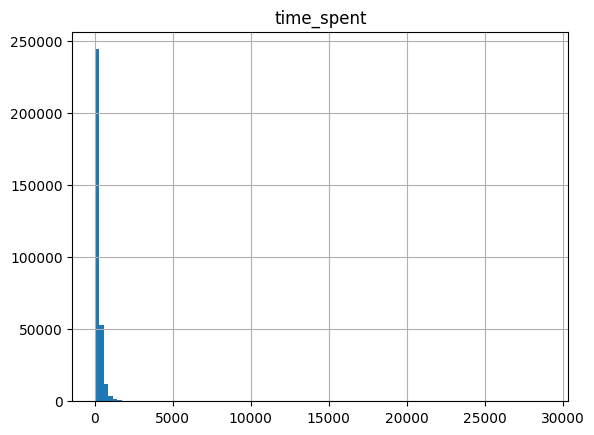

In [11]:
data.hist('time_spent', bins=100)

4.3 Выведите гистограмму значений времени, проведённого на АЗС, с увеличенным до 100 числом столбцов и диапазоном значений от 0 до 1500.

array([[<Axes: title={'center': 'time_spent'}>]], dtype=object)

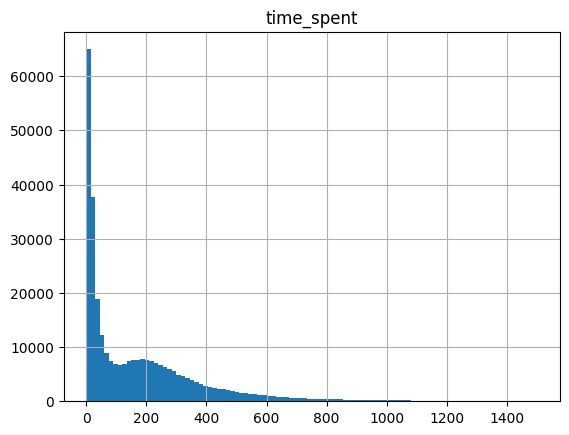

In [16]:
data.hist('time_spent', bins=100, range = (0, 1500))

5.1 Будем бросать на стол 10 монет и считать количество выпавших орлов. 

Функции для имитации одного броска и подсчёта числа орлов в нескольких бросках уже в прекоде.

 Мы повторили эксперимент 1000 раз и сохранили результат в переменной df_experiments.
 
Постройте гистограмму полученных значений с диапазоном значений от 0 до 10 и количеством корзин 11.

In [17]:
import random

In [18]:

# Функция, имитирующая один бросок монеты.
# От англ. coin - монета, flip - бросок монеты.
def coin_flip():
    # возможны два варианта:
    # - выпала решка, это +0 орлов
    # - выпал орёл, это +1 орёл
    score = random.randint(0, 1)
    return score

# Функция для суммирования числа орлов в нескольких бросках.
# Орёл и решка переводятся на английский как heads и tails.
# Аргумент repeat говорит, сколько раз бросать монету
# (от англ. repeat - повторение).
def flips_heads(repeat):
    total = 0
    for i in range(repeat):
        flip = coin_flip()
        total += flip
    return total



[[<Axes: title={'center': '0'}>]]


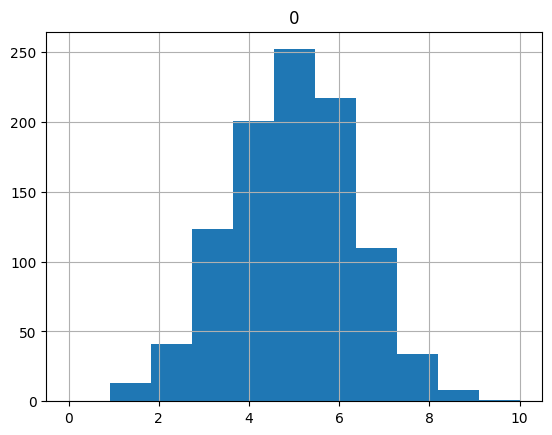

In [19]:
# Cоздаём пустой список. В него мы
# будем складывать результаты экспериментов.
experiments = []

for i in range(1000):
    score = flips_heads(10)
    # Напомним: функция append() добавляет новый
    # элемент score в конец списка experiments.
    experiments.append(score)


# превращаем список в DataFrame
df_experiments = pd.DataFrame(experiments)

# постройте гистограмму для df_experiments
print(df_experiments.hist(bins=11, range=(0,10)))

5.2 Валерик каждый день едет на работу с тремя пересадками: сперва на автобусе до метро; затем по одной ветке, а потом по другой; и от метро добирается до работы на автобусе.

Валерик знает, сколько продолжается поездка на каждом виде транспорта и пересадки, но вечно забывает учесть ожидание автобусов и поездов. 
 
Постройте гистограмму опозданий Валерика за 5 лет c параметром bins=10.

Будем считать, что автобус прибывает за время от 0 до 10 минут, а поезд — за время от 0 до 5 минут. В прекоде мы уже написали функции, которые это имитируют.

In [22]:
# Функция, имитирующая время ожидания автобуса.
# (от англ. bus - автобус, wait - ждать, time - время)
def bus_wait_time():
    return random.randint(0, 10)
# Функция, имитирующая время ожидания поезда в метро.
# (от англ. train - поезд, wait - ждать, time - время)
def train_wait_time():
    return random.randint(0, 5)

In [23]:

# Функция подсчёта полного опоздания за день.
# от англ. total - полный, итоговый, delay - задержка, опоздание
def total_delay():
    # обратите внимание, как в Python переносят длинные строки
    return (bus_wait_time() + 
            train_wait_time() + 
            train_wait_time() + 
            bus_wait_time())

In [24]:
days = []
for i in range(365 * 5):
        delay = total_delay()
        days.append(delay) 

In [25]:
# превращаем список в DataFrame
df_days = pd.DataFrame(days)

array([[<Axes: title={'center': '0'}>]], dtype=object)

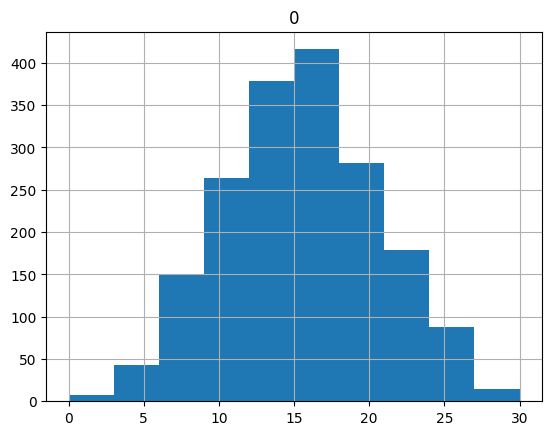

In [26]:
df_days.hist(bins=10)

6. Нарисуйте диаграмму размаха для data, ограничив диапазон по вертикали значениями -100 и 1000.

(-100.0, 1000.0)

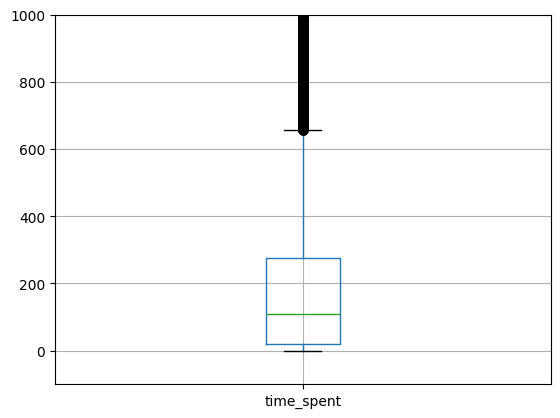

In [35]:
data.boxplot()
plt.ylim(-100, 1000)


7. Методом describe() получите характерные значения таблицы data. Результат выведите на экран.

In [33]:
data.describe()

,time_spent
count,317104.000000
mean,203.382294
std,395.754791
min,0.000000
25%,19.000000
50%,108.000000
75%,274.000000
max,28925.000000
